# ChurnGuard: EDA и эксперименты

Цель ноутбука - зафиксировать ход анализа для итогового проекта: структура данных, признаки, baseline, улучшенная модель и выбор финального решения.

## Данные

Используется синтетическая выборка `data/churn_train.csv`. Признаки описывают профиль клиента подписочного сервиса: срок пользования, платежи, обращения в поддержку, тип договора и удовлетворенность. Целевая переменная `churn` равна 1, если клиент ушел.

In [2]:
import pandas as pd

data = pd.read_csv('../data/churn_train.csv')
data.head()

,age,tenure_months,monthly_spend,support_tickets,late_payments,contract_type,has_autopay,uses_mobile_app,satisfaction_score,churn
0,23,64,43.33,1,0,one-year,0,1,2.6,0
1,62,35,46.06,0,0,one-year,0,1,10.0,0
2,55,71,119.06,1,1,one-year,0,0,9.8,0
3,43,55,104.64,1,0,one-year,0,1,7.8,0
4,43,47,55.94,0,0,one-year,1,1,7.3,0


In [3]:
data.describe(include='all')

,age,tenure_months,monthly_spend,support_tickets,late_payments,contract_type,has_autopay,uses_mobile_app,satisfaction_score,churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,month-to-month,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,653,NaN,NaN,NaN,NaN
mean,46.746667,36.265833,63.823342,1.154167,0.428333,NaN,0.565833,0.661667,7.044250,0.270833
std,16.666702,20.917372,22.219981,1.077667,0.640473,NaN,0.495854,0.473340,1.720586,0.444575
min,18.000000,1.000000,15.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.500000,0.000000
25%,32.000000,18.000000,48.820000,0.000000,0.000000,NaN,0.000000,0.000000,5.900000,0.000000
50%,47.000000,35.000000,64.775000,1.000000,0.000000,NaN,1.000000,1.000000,7.000000,0.000000
75%,61.000000,54.000000,78.402500,2.000000,1.000000,NaN,1.000000,1.000000,8.300000,1.000000


## Эксперименты

Baseline: `LogisticRegression`. Улучшенная модель: `RandomForestClassifier`. Финальная модель выбирается не только по accuracy, но и по recall/F1, потому что для задачи удержания важно не пропустить клиента с высоким риском оттока.

In [4]:
import json

with open('../artifacts/metrics.json', encoding='utf-8') as file:
    metrics = json.load(file)
metrics

{'logistic_regression': {'accuracy': 0.7917,
  'precision': 0.6744,
  'recall': 0.4462,
  'f1': 0.537,
  'roc_auc': 0.7956},
 'random_forest': {'accuracy': 0.7542,
  'precision': 0.5429,
  'recall': 0.5846,
  'f1': 0.563,
  'roc_auc': 0.7864},
 'final_model': 'random_forest',
 'test_size': 0.2,
 'n_train': 960,
 'n_test': 240}

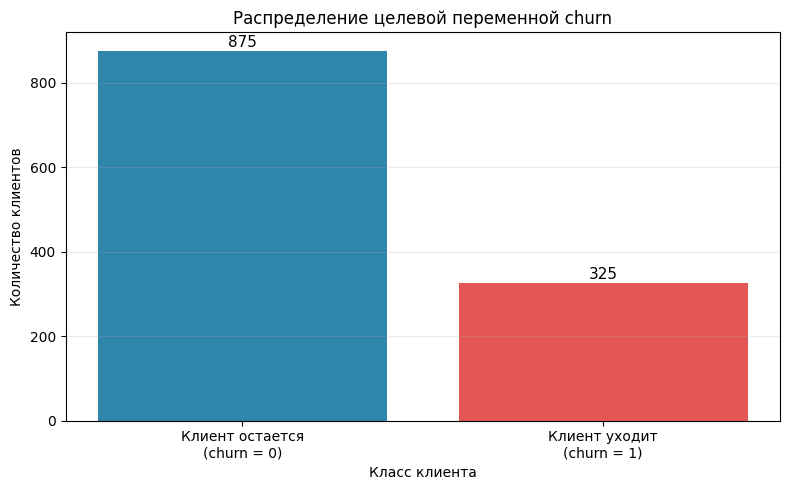

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("../data/churn_train.csv")

class_counts = data["churn"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Клиент остается\n(churn = 0)", "Клиент уходит\n(churn = 1)"],
    class_counts.values,
    color=["#2E86AB", "#E45756"]
)

plt.title("Распределение целевой переменной churn")
plt.xlabel("Класс клиента")
plt.ylabel("Количество клиентов")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 10,
        str(value),
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.savefig(
    "../artifacts/figure_1_1_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Вывод

Финальной выбрана Random Forest: у нее выше recall и F1 для класса оттока. Это соответствует бизнес-сценарию, где важнее найти больше потенциально уходящих клиентов.